# Testing stuff
Here I am testing python modules and data processing techniques, to get familiar with tools.

In [20]:
import torch

torch.manual_seed(69)

print("Testing concatenations....")
a = torch.randn(5,3)
b = torch.randn(5,3)
print("A", a)
print("B", b)
print("Concatenated:", torch.cat((a, b), dim=1))

Testing concatenations....
A tensor([[-0.5259, -2.6043, -0.6448],
        [ 1.4356, -0.5796, -0.7254],
        [ 1.6112, -0.0703,  0.4757],
        [-0.3330, -0.0810, -1.2897],
        [-1.1969,  0.6707, -1.2555]])
B tensor([[-1.1164,  1.2523, -1.5541],
        [-1.4058, -0.3329, -0.2117],
        [-0.4752,  0.0606,  1.9731],
        [ 0.1399,  0.1372, -2.0599],
        [ 1.1843,  0.4051, -0.0157]])
Concatenated: tensor([[-0.5259, -2.6043, -0.6448, -1.1164,  1.2523, -1.5541],
        [ 1.4356, -0.5796, -0.7254, -1.4058, -0.3329, -0.2117],
        [ 1.6112, -0.0703,  0.4757, -0.4752,  0.0606,  1.9731],
        [-0.3330, -0.0810, -1.2897,  0.1399,  0.1372, -2.0599],
        [-1.1969,  0.6707, -1.2555,  1.1843,  0.4051, -0.0157]])


## Exploring candidate datasets for training

### IOTID20
Apparently, this dataset is imbalanced, gives mainly focus on mirai attacks. Benign traffic is a minority.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 625783 entries, 2019-07-25 03:25:53 to 2019-07-25 03:25:10
Data columns (total 81 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Src_Port           625783 non-null  int64  
 1   Dst_Port           625783 non-null  int64  
 2   Protocol           625783 non-null  int64  
 3   Flow_Duration      625783 non-null  int64  
 4   Tot_Fwd_Pkts       625783 non-null  int64  
 5   Tot_Bwd_Pkts       625783 non-null  int64  
 6   TotLen_Fwd_Pkts    625783 non-null  float64
 7   TotLen_Bwd_Pkts    625783 non-null  float64
 8   Fwd_Pkt_Len_Max    625783 non-null  float64
 9   Fwd_Pkt_Len_Min    625783 non-null  float64
 10  Fwd_Pkt_Len_Mean   625783 non-null  float64
 11  Fwd_Pkt_Len_Std    625783 non-null  float64
 12  Bwd_Pkt_Len_Max    625783 non-null  float64
 13  Bwd_Pkt_Len_Min    625783 non-null  float64
 14  Bwd_Pkt_Len_Mean   625783 non-null  float64
 15  Bwd_Pkt_Len_Std  

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Category,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-07-25 03:25:53,10000,10101,17,75,1,1,982.0,1430.0,982.0,982.0,...,0.0,0.0,0.0,0.0,75.00,0.000000,75.0,75.0,Mirai,Mirai-Ackflooding
2019-05-26 22:11:06,2179,554,6,5310,1,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2655.00,2261.327486,4254.0,1056.0,DoS,DoS-Synflooding
2019-07-11 01:24:48,52727,9020,6,141,0,3,0.0,2806.0,0.0,0.0,...,0.0,0.0,0.0,0.0,70.50,0.707107,71.0,70.0,Scan,Scan Port OS
2019-09-04 03:58:17,52964,9020,6,151,0,2,0.0,2776.0,0.0,0.0,...,0.0,0.0,0.0,0.0,151.00,0.000000,151.0,151.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:41:18,36763,1900,17,153,2,1,886.0,420.0,452.0,434.0,...,0.0,0.0,0.0,0.0,76.50,0.707107,77.0,76.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:39:13,41980,443,6,157,2,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,78.50,6.363961,83.0,74.0,Mirai,Mirai-Hostbruteforceg
2019-07-25 03:21:01,60175,8899,17,139,20,1,640.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,6.95,1.669384,10.0,4.0,Mirai,Mirai-UDP Flooding
2019-07-11 01:52:37,41467,443,6,112,0,2,0.0,2896.0,0.0,0.0,...,0.0,0.0,0.0,0.0,112.00,0.000000,112.0,112.0,Scan,Scan Port OS
2019-07-25 03:21:13,60132,8899,17,86,1,1,32.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,86.00,0.000000,86.0,86.0,Mirai,Mirai-UDP Flooding


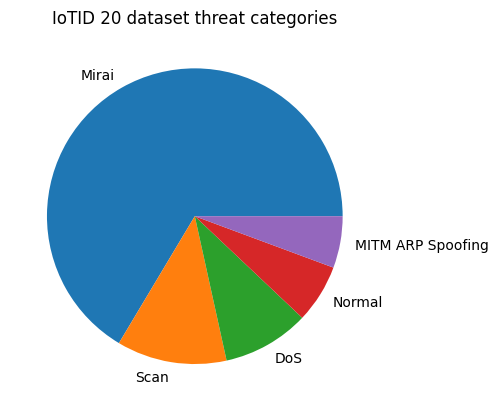

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/iotid20/iotid20.csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
categories = df["Category"].value_counts()

def percent_formatter(x):
    return "{}\n({:.1f})%".format(int(categories.sum()*x/100) ,x)

plt.pie(categories.values, labels=categories.index)
plt.title("IoTID 20 dataset threat categories")
df.info(verbose=True)
print(df.columns.to_list())
head_data = df.head(10)
del df
head_data

### IoT-23

This is a large dataset. Split up to multiple csvs according to attack vector. A large portion of data are benign traffic. Contains the following attack types:
- Command and Control
- DDoS
- Malicious file downloads
- Mirai
- Okiru
- Port scan
- Heartbeat
- Torii

In [4]:
import pandas as pd

df = pd.read_csv("../datasets/IoT-23/attacks/DDoS[1].csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
df.shape[1]
df.info()
head_data = df.head(10)
del df 
head_data

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5393746 entries, 2018-07-20 17:44:44 to 2018-09-06 15:05:19
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Src_Port           int64  
 1   Dst_Port           int64  
 2   Protocol           int64  
 3   Flow_Duration      int64  
 4   Tot_Fwd_Pkts       int64  
 5   Tot_Bwd_Pkts       int64  
 6   TotLen_Fwd_Pkts    float64
 7   TotLen_Bwd_Pkts    float64
 8   Fwd_Pkt_Len_Max    float64
 9   Fwd_Pkt_Len_Min    float64
 10  Fwd_Pkt_Len_Mean   float64
 11  Fwd_Pkt_Len_Std    float64
 12  Bwd_Pkt_Len_Max    float64
 13  Bwd_Pkt_Len_Min    float64
 14  Bwd_Pkt_Len_Mean   float64
 15  Bwd_Pkt_Len_Std    float64
 16  Flow_Byts/s        float64
 17  Flow_Pkts/s        float64
 18  Flow_IAT_Mean      float64
 19  Flow_IAT_Std       float64
 20  Flow_IAT_Max       float64
 21  Flow_IAT_Min       float64
 22  Fwd_IAT_Tot        float64
 23  Fwd_IAT_Mean       float64
 24  Bwd_IAT_Mean     

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-07-20 17:44:44,2074,80,17,1678539,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:11,8356,80,17,34506819,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,3.450682e+07,0.000000e+00,3.450682e+07,3.450682e+07,DDoS
2018-07-20 17:44:23,49635,80,17,3757355,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:24,41458,80,17,26676285,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,2.667628e+07,0.000000e+00,2.667628e+07,2.667628e+07,DDoS
2018-07-20 17:44:23,41910,80,17,9054086,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:35,4391,80,17,15388975,4,0,2048.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,6.697604e+06,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:21,54802,80,17,25820274,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,7.660620e+14,1.083370e+15,1.532120e+15,6.854589e+06,DDoS
2018-07-20 17:44:17,14609,80,17,11944688,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:37,33252,80,17,11001973,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,1.100197e+07,0.000000e+00,1.100197e+07,1.100197e+07,DDoS


### IDS-2018

This is a realistic environment dataset, covering a large range of cyber attacks

15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15997164 entries, 0 to 15997163
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Timestamp  object
 1   Label      object
dtypes: object(2)
memory usage: 244.1+ MB
Label
Benign                      13248929
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64


,Timestamp,Label
0,21/02/2018 08:33:25,Benign
1,21/02/2018 08:33:06,Benign
2,21/02/2018 08:33:06,Benign
3,21/02/2018 08:33:11,Benign
4,21/02/2018 08:33:11,Benign
...,...,...
15997159,02/03/2018 02:08:18,Benign
15997160,02/03/2018 02:08:22,Benign
15997161,02/03/2018 02:08:25,Benign
15997162,02/03/2018 02:08:29,Benign


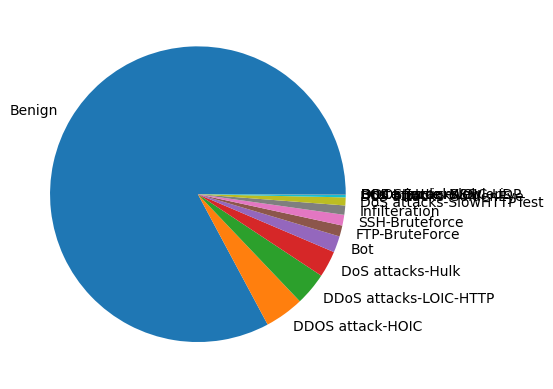

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/ids-2018/ids-2018-merged.csv", usecols=["Timestamp","Label"])
categories = df["Label"].value_counts()
print(categories.shape[0])
df.info()
print(categories)
plt.pie(categories.values, labels=categories.index)
df

In [ ]:
import pandas as pd

df = pd.read_csv("../datasets/ids-2018/ids-2018-merged.csv", nrows=5e+6)
df = df.drop(columns=["Src IP", "Dst IP", "Timestamp", "Label"])
df.info()
df

[ 0  4  3  1  2  9  8  6  5  7 10]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 83 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Src IP             int64  
 1   Src Port           int64  
 2   Dst IP             int64  
 3   Dst Port           int64  
 4   Protocol           int64  
 5   Timestamp          object 
 6   Flow Duration      int64  
 7   Tot Fwd Pkts       int64  
 8   Tot Bwd Pkts       int64  
 9   TotLen Fwd Pkts    int64  
 10  TotLen Bwd Pkts    int64  
 11  Fwd Pkt Len Max    int64  
 12  Fwd Pkt Len Min    int64  
 13  Fwd Pkt Len Mean   float64
 14  Fwd Pkt Len Std    float64
 15  Bwd Pkt Len Max    int64  
 16  Bwd Pkt Len Min    int64  
 17  Bwd Pkt Len Mean   float64
 18  Bwd Pkt Len Std    float64
 19  Flow Byts/s        float64
 20  Flow Pkts/s        float64
 21  Flow IAT Mean      float64
 22  Flow IAT Std       float64
 23  Flow IAT Max       int64  
 24  Flow IAT Min   

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,0,80,6,21/02/2018 08:33:25,37953,5,3,135,...,32,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
1,0,0,0,500,17,21/02/2018 08:33:06,117573474,3,0,1500,...,8,0.0,0.000,0,0,58800000.0,2.380000e+07,75600000,42000000,Benign
2,0,0,0,500,17,21/02/2018 08:33:06,117573474,3,0,1500,...,8,0.0,0.000,0,0,58800000.0,2.380000e+07,75600000,42000000,Benign
3,0,0,0,500,17,21/02/2018 08:33:11,99743998,5,0,2500,...,8,4000290.0,0.000,4000290,4000290,31900000.0,3.790000e+07,75600000,7200397,Benign
4,0,0,0,500,17,21/02/2018 08:33:11,99743999,5,0,2500,...,8,4000286.0,0.000,4000286,4000286,31900000.0,3.790000e+07,75600000,7200399,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,0,0,0,443,6,28/02/2018 02:51:21,5349532,8,6,353,...,20,287228.0,0.000,287228,287228,5062264.0,0.000000e+00,5062264,5062264,Benign
4999996,0,0,0,52799,6,28/02/2018 02:51:26,1,2,0,31,...,20,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
4999997,0,0,0,445,6,28/02/2018 02:51:27,7920660,2,0,0,...,20,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
4999998,0,0,0,443,6,28/02/2018 02:49:41,119929186,12,11,597,...,20,1542212.5,1773295.821,2796122,288303,58400000.0,5.052285e+05,58700000,58000000,Benign


## Embeddings

Experiments using embeddings. Embeddings are usually required when categorical data are present which affect output in non-linear way. With embeddings we enable models to learn more about each category

## Convolution and Pooling

Here convolution and pooling is tested, as its provided from PyTorch

In [21]:
import torch
import torch.nn as nn 

torch.manual_seed(42)
X = torch.randn(5,3)
print(X)
maxpool = nn.MaxPool1d(3, 1)
conv = nn.Conv1d(5, 3, 1)
relu = nn.ReLU()
print(relu(maxpool(X)))
print(conv(X))

tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])
tensor([[0.3367],
        [0.2303],
        [2.2082],
        [0.8094],
        [1.1103]])
tensor([[ 0.0440,  0.1636,  0.2348],
        [-0.0539,  0.5779,  0.4548],
        [ 0.6880, -1.4024, -0.5970]], grad_fn=<SqueezeBackward1>)


In [ ]:
import pandas as pd
import torch

df = pd.read_csv("../datasets/ddos-2019/cicddos2019_dataset.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

p = torch.tensor([[1,1],[2, float('nan')], [3, 1], [4,2]])
print(p[~p[:,1].isnan(), 1].mean().item())

p = torch.tensor([[1,1],[2, 0], [3, 1], [4,2]])
mode = p[:,1].mode().values.item()
p[p[:,1] == 0 , 1] = mode
print(p)

df.info()

True
1.3333333730697632
tensor([[1, 1],
        [2, 1],
        [3, 1],
        [4, 2]])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 79 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  431371 non-null  int64  
 1   Flow Duration             431371 non-null  int64  
 2   Total Fwd Packets         431371 non-null  int64  
 3   Total Backward Packets    431371 non-null  int64  
 4   Fwd Packets Length Total  431371 non-null  float64
 5   Bwd Packets Length Total  431371 non-null  float64
 6   Fwd Packet Length Max     431371 non-null  float64
 7   Fwd Packet Length Min     431371 non-null  float64
 8   Fwd Packet Length Mean    431371 non-null  float64
 9   Fwd Packet Length Std     431371 non-null  float64
 10  Bwd Packet Length Max     431371 non-null  float64
 11  Bwd Packet Length Min     431371 non-null  float64
 12  Bwd Packet 

## Processing LARGE CSVs

Dask to the rescue! Dask is a parallel processing python library which can process data fast in a very memory efficient way, unlike pandas. Can be installed via PIP:

`pip install dask[complete]`

And get the blocks of dataframe using to_delayed method. Dask can be integrated to pytorch using an iterable dataset. However iterable datasets do not support Subset of Pytorch, for Subset it must be mappable, that is override `__getitem__` instead:

```python
from torch.utils.data import IterableDataset

class DaskColumnDataset(IterableDataset):
    def __init__(self, ddf, column_name):
        self.ddf = ddf[column_name]

    def __iter__(self):
        # Iterate over partitions
        for part in self.ddf.to_delayed():
            # Each partition is computed separately
            col_np = part.compute().to_numpy()
            for val in col_np:
                yield torch.tensor(val)  # or yield val if already tensor-compatible

# Usage
ddf = dd.read_csv('your_file.csv')
dataset = DaskColumnDataset(ddf, 'your_column_name')
loader = torch.utils.data.DataLoader(dataset, batch_size=32)

for batch in loader:
    # Use batch in your training loop
    ...

```

In [8]:
import dask.dataframe
import numpy as np

ddf = dask.dataframe.read_csv("../datasets/IoT-23/IoT-23-merged.csv", blocksize="100M")
# Categorize
ddf = ddf.categorize(columns=["Sub Cat"])
ddf = ddf.replace([np.inf, -np.inf], np.nan)
np.set_printoptions(threshold=100)
# Compute the column first (as a Pandas Series), then access .cat.codes
codes_ddf = ddf.map_partitions(lambda df: df["Sub Cat"].cat.codes)
unique_codes = codes_ddf.unique().compute()
print(codes_ddf.nunique().compute())
# Step 2: Compute all means at once — returns a Pandas Series
col_means = ddf.mean(numeric_only=True, skipna=True).compute()
# Step 3: Fill NaNs in only those columns
for col, mean_val in col_means.items():
    if not np.isnan(mean_val):
        ddf[col] = ddf[col].fillna(mean_val)
print(unique_codes, len(unique_codes))
codes_array = codes_ddf.compute().to_numpy()
print(codes_array.shape)

10
0    4
0    3
0    1
0    7
0    0
0    6
0    2
0    5
0    9
0    8
dtype: int8 10
(37427467,)


## SHAP shenanigans

SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model. To be filled with more details

CUDA available! GPU device name is: NVIDIA GeForce RTX 4060
Chunk shape: (3000000, 79) Datatypes: Src Port         float32
Dst Port         float32
Protocol         float32
Flow Duration    float32
Tot Fwd Pkts     float32
                  ...   
Active Min       float32
Idle Mean        float32
Idle Std         float32
Idle Max         float32
Idle Min         float32
Length: 79, dtype: object
Chunk shape: (3000000, 79) Datatypes: Src Port         float32
Dst Port         float32
Protocol         float32
Flow Duration    float32
Tot Fwd Pkts     float32
                  ...   
Active Min       float32
Idle Mean        float32
Idle Std         float32
Idle Max         float32
Idle Min         float32
Length: 79, dtype: object
Chunk shape: (3000000, 79) Datatypes: Src Port         float32
Dst Port         float32
Protocol         float32
Flow Duration    float32
Tot Fwd Pkts     float32
                  ...   
Active Min       float32
Idle Mean        float32
Idle Std         float32

/home/sbaltsas/Visual Studio Code Projects/thesis/.venv/lib64/python3.13/site-packages/torcheval/metrics/functional/classification/accuracy.py:275: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:232.)
  num_correct = mask.new_zeros(num_classes).scatter_(0, target, mask, reduce="add")


Testset accuracy: 95.264%, average loss: 1.1813764382742782e-10
Accuracy per class:
PartOfAHorizontalPortScan: 99.96186828613281 %
C&C: 16.169113159179688 %
HeartBeat: 0.0 %
Attack: 1.1134811639785767 %
DDoS: 99.88016510009766 %
C&C-Torii: 94.03390502929688 %
Okiru: 99.92227935791016 %
Mirai: 0.0 %
FileDownload: 7.267297267913818 %
Normal: 99.82103729248047 %
--------------------------------------------------
base values [ -7.373836 -32.67664  -32.871235 -12.848627 -19.39203  -48.7537
 -10.451712 -77.28966  -22.293917 -16.360992]
features 79
shap 0 value shape (79, 10)
test values shape torch.Size([10, 79])
[[[ 2.49492385e-01  5.20667490e-02 -5.91662368e-02 ... -1.21786833e-01
    7.18588240e-02 -9.30749476e-02]
  [-2.26579893e+01  1.32859881e+01  1.14208749e+01 ...  2.67119670e+01
    8.03988230e+00  9.39016189e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [-4.35064318e-10 -3.14210069e-10 -3.44664250e-10 ... -6.

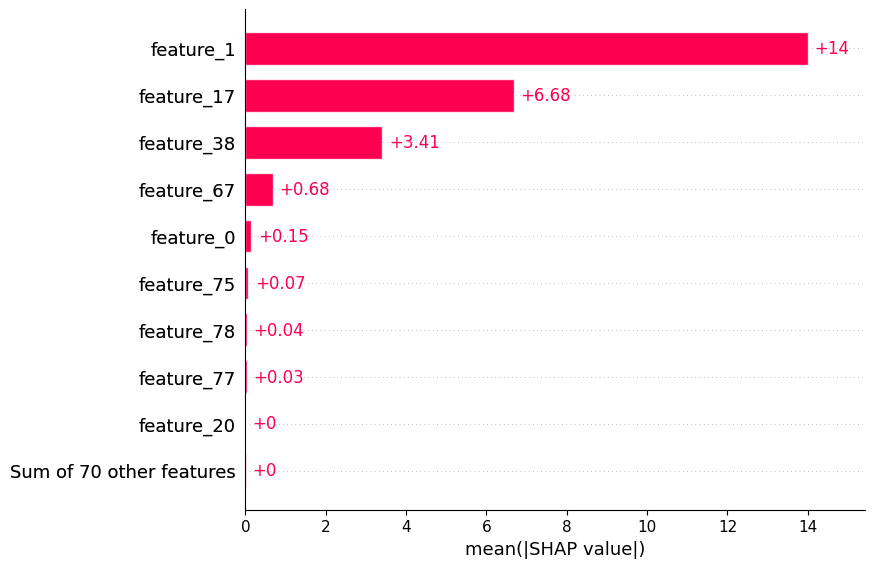

In [ ]:
import torch
import torch.nn as nn
#import torchinfo
from torcheval.metrics import MulticlassAccuracy
from torch.utils.data import random_split, DataLoader, TensorDataset, Subset
from sklearn.model_selection import StratifiedKFold
import dataset_utils

# CODE TO CHECK ON TRAINER, FOR TRAINING SPEED BOOST. WORKS ON AMPERE GPU DEVICES OR NEWER
# scaler = torch.cuda.amp.GradScaler()

# for data, label in train_loader:
#     data = data.to(DEVICE)
#     label = label.to(DEVICE)
#     optimizer.zero_grad()

#     with torch.cuda.amp.autocast():
#         output = model(data)
#         loss = loss_function(output, label)

#     scaler.scale(loss).backward()
#     scaler.step(optimizer)
#     scaler.update()

SEED = 42
if torch.cuda.is_available():
    print("CUDA available! GPU device name is:", torch.cuda.get_device_name())
    DEVICE = "cuda"
else:
    print("CUDA is not available")
    DEVICE = "cpu"


class EncoderTransformer(nn.Module):
    def __init__(self, feature_dim: int, embedding_dim:int = 128, num_heads:int = 8, dropout:float = 0.0, epsilon=1e-6, ff_neurons=256):
        super().__init__()
        self.input_projection = nn.Linear(feature_dim, embedding_dim)
        self.multihead_attention = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.normalization = nn.LayerNorm(normalized_shape=embedding_dim, eps=epsilon)
        self.ff_net = nn.Sequential(
            nn.Linear(embedding_dim, ff_neurons),
            nn.ReLU(),
            nn.Linear(ff_neurons, embedding_dim)
        )
    
    def forward(self, x):
        input = self.input_projection(x)
        x = self.normalization(input)
        x, _ = self.multihead_attention(x, x, x)
        res = x + input
        x = self.dropout(res)
        x = self.normalization(x)
        x = self.ff_net(x)
        res = x + res
        res = self.normalization(res)
        return res


class MLPClassifier(nn.Module):
    def __init__(self, feature_dim: int, n_classes: int, dropout:float = 0.1, hidden_neurons=256):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(feature_dim, hidden_neurons),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_neurons, n_classes)
        )

    def forward(self, x):
        return self.layers(x)
    

class MyModel(nn.Module):
    def __init__(self, num_features: int, num_classes: int, num_encoders:int = 1, num_mlps:int = 1):
        super().__init__()
        layer_list = []
        for _ in range(num_encoders):
            layer_list.append(EncoderTransformer(num_features))
        for _ in range(num_mlps):
            layer_list.append(MLPClassifier(128, num_classes))
        self.layers = nn.Sequential(*layer_list)


    def forward(self, x):
        return self.layers(x)


def _correct(output: torch.Tensor, target: torch.Tensor):
    predicted = output.argmax(dim=1)
    return (predicted == target).sum().item()


def train_model(model: nn.Module, train_loader: DataLoader, loss_function = nn.CrossEntropyLoss(), epochs: int = 30, learning_rate: int = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(epochs):
        model.train()
        batch_number = len(train_loader)
        samples = len(train_loader.dataset)
        total_loss = 0
        total_correct = 0
        for data, label in train_loader:
            data = data.to(DEVICE)
            label = label.to(DEVICE)
            output = model(data)
            loss = loss_function(output, label)
            total_loss += loss.item()
            total_correct += _correct(output, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss = total_loss/batch_number
        train_accuracy = total_correct/samples
        print("="*50)
        print(f"Epoch {epoch+1}/{epochs}. Average accuracy: {train_accuracy*100:.3f}%, average loss: {train_loss:.5f}, current loss: {loss:.5f}.")


def test_model(model: nn.Module, test_loader: DataLoader, metric, loss_function = nn.CrossEntropyLoss()) -> torch.Tensor:
    model.eval()
    num_batches = len(test_loader)
    num_items = len(test_loader.dataset)
    test_loss = 0
    total_correct = 0
    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(DEVICE)
            label = label.to(DEVICE)
            output = model(data)
            loss = loss_function(output, label)
            test_loss = loss.item()
            total_correct += _correct(output, label)
            metric.update(output, label)
    test_loss = test_loss/num_batches
    accuracy = total_correct/num_items
    print(f"Testset accuracy: {100*accuracy:.3f}%, average loss: {test_loss}")
    return metric.compute()


if __name__ == "__main__":
    torch.manual_seed(SEED)
    X, y, label_map = dataset_utils.dataset_to_tensor(dataset_utils.MERGED_DATASET_PATH, "Sub_Cat", chunk_size=3e+6)
    dataset = TensorDataset(X, y)
    #train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])
    batch_size = 1024
    folds = 2
    num_features = X.shape[1]
    num_classes = len(label_map)
    metric = MulticlassAccuracy(average=None, num_classes=num_classes, device=DEVICE)
    print(f"# of rows: {X.shape[0]}, # of features: {num_features}, # of classes: {num_classes}, datatype: {X.dtype}")
    #model = MyModel(num_features, num_classes).to(DEVICE)
    #torchinfo.summary(model, (batch_size, num_features))
    strat_kfold = StratifiedKFold(n_splits=folds, shuffle=True, random_state=SEED)
    final_model = None
    for fold, (train_index, test_index) in enumerate(strat_kfold.split(X, y)):
        model = MyModel(num_features, num_classes).to(DEVICE)
        print("-"*50)
        print(f"Fold {fold+1}/{folds}")
        train_dataset = Subset(dataset, train_index)
        test_dataset = Subset(dataset, test_index)
        train_loader = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size, pin_memory=True)
        print("STARTING TRAINING SESSION!!!")
        train_model(model, train_loader, epochs=3)
        print("TRAINING COMPLETE. STARTING TESTING SESSION!!!")
        multiclass_accuracy = test_model(model, test_loader, metric)
        print("Accuracy per class:")
        for i, class_accuracy in enumerate(multiclass_accuracy):
            print(f"{label_map[i]}: {class_accuracy*100} %")
        print("-"*50)
        final_model = model
        break

    import shap
    from shap.plots import bar
    final_model = final_model.to("cpu")
    shap_batch_loader = DataLoader(dataset, 110, shuffle=True)
    features, _ = next(iter(shap_batch_loader))
    features = features.cpu().detach()
    final_model.eval()
    background = features[:100]
    test_values = features[100:]
    with torch.no_grad():
        base_values = final_model(background).mean(dim=0).numpy()
    explainer = shap.GradientExplainer(final_model,background)
    shap_values = explainer.shap_values(test_values)
    # Create Explanation object for class 0 (you can loop for others)
    shap_explanation = shap.Explanation(
        values=shap_values[0].T,                           # SHAP values for class 0
        base_values=base_values[0],                      # base value for class 0
        data=features[100:].numpy(),                  # input data
        feature_names=[f'feature_{i}' for i in range(features.shape[1])]
    )
    print("base values", base_values)
    print("features", features.shape[1])
    print("shap 0 value shape", shap_values[0].shape)
    print("test values shape", test_values.shape)
    print(shap_values)
    shap.initjs()
    bar(shap_explanation, max_display=10)
